In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class GeneticAlgorithm:
  def __init__(self, point_size, map_size, fitness_function, population_size, selection_ratio, mutation_possibility, mutation_ratio, max_iter, termination_value) -> None:
    if point_size < 1:
      raise ValueError("point_size must be at least 1")
    if map_size < 1:
      raise ValueError("map_size must be at least 1")
    if mutation_possibility < 0 or mutation_possibility > 1:
      raise ValueError("mutation_possibility must be between 0 and 1")
    if mutation_ratio < 0 or mutation_ratio > 1:
      raise ValueError("mutation_ratio must be between 0 and 1")
    if selection_ratio < 0 or selection_ratio > 1:
      raise ValueError("selection_ratio must be between 0 and 1")
    if population_size % 2 != 0:
      raise ValueError("population_size must be even")
    if population_size < 4:
      raise ValueError("population_size must be at least 4")
    if max_iter < 1:
      raise ValueError("max_iter must be at least 1")

    self.point_size = point_size
    self.map_size = map_size
    self.fitness_function = fitness_function
    self.population_size = population_size
    self.selection_amount = int(selection_ratio * population_size)
    self.mutation_possibility = mutation_possibility
    self.mutation_ratio = mutation_ratio
    self.max_iter = max_iter
    self.termination_value = termination_value

  def optimize(self):
    points = [np.random.random(size=self.point_size) * self.map_size for _ in range(self.population_size)]
    iter_count = 0

    best_point, best_score = None, np.inf

    history = {}
    while best_score >= self.termination_value and iter_count < self.max_iter:
      points = sorted(points, key=lambda x: self.fitness_function(x))
      best_point = points[0]
      best_score = self.fitness_function(best_point)
      best_points = points[:self.selection_amount]
      history[iter_count] = {
          "best_point": best_point,
          "best_score": best_score,
          "points": points
      }
      print(f"iter {iter_count}: {best_score}")

      new_kids = []
      num_kids_to_create = self.population_size - self.selection_amount
      for i in range(num_kids_to_create):
          indices = np.random.choice(len(best_points), size=2, replace=False)
          p_a, p_b = best_points[indices[0]], best_points[indices[1]]

          new_kid = (p_a + p_b) / 2
          mutation = np.random.random() < self.mutation_possibility
          if mutation:
              new_kid += np.random.uniform(-1, 1, size=self.point_size) * self.mutation_ratio * self.map_size
          new_kids.append(new_kid)

      points = new_kids + best_points
      iter_count += 1

    return best_point, best_score, history

In [3]:
target_point = (np.random.random(size=3) * 400).round(5)
print(f"Target Point: {target_point}")

Target Point: [369.20479 362.58289  25.43159]


In [4]:
model = GeneticAlgorithm(
    point_size = 3,
    map_size = 400,
    fitness_function = lambda x: np.linalg.norm(x - target_point),
    population_size = 150,
    selection_ratio = 0.7,
    mutation_possibility = 0.5,
    mutation_ratio = 0.3,
    max_iter = 1000,
    termination_value = 1
)

In [5]:
best_point, best_score, history = model.optimize()
print(f"Best point: {best_point}")
print(f"Best score: {best_score}")

iter 0: 123.96254398330169
iter 1: 72.29668271806607
iter 2: 58.89700513965573
iter 3: 58.89700513965573
iter 4: 58.89700513965573
iter 5: 50.69910069885582
iter 6: 34.42138395881991
iter 7: 21.82260700961294
iter 8: 21.82260700961294
iter 9: 21.82260700961294
iter 10: 21.18685365168416
iter 11: 18.154991607488554
iter 12: 18.154991607488554
iter 13: 3.576320065253565
iter 14: 3.576320065253565
iter 15: 3.576320065253565
iter 16: 3.576320065253565
iter 17: 3.576320065253565
iter 18: 3.576320065253565
iter 19: 3.093798587073305
iter 20: 3.093798587073305
iter 21: 3.093798587073305
iter 22: 2.509631360120783
iter 23: 2.509631360120783
iter 24: 2.509631360120783
iter 25: 2.509631360120783
iter 26: 2.509631360120783
iter 27: 1.7695446720497672
iter 28: 1.4243923314583846
iter 29: 1.4243923314583846
iter 30: 1.2823516901231746
iter 31: 1.2823516901231746
iter 32: 1.2823516901231746
iter 33: 1.2823516901231746
iter 34: 1.2823516901231746
iter 35: 1.2823516901231746
iter 36: 1.282351690123174

In [6]:
iters, best_scores = [], []
for key, value in history.items():
  iters.append(key)
  best_scores.append(value["best_score"])

Text(0.5, 1.0, 'Best Score vs Iteration')

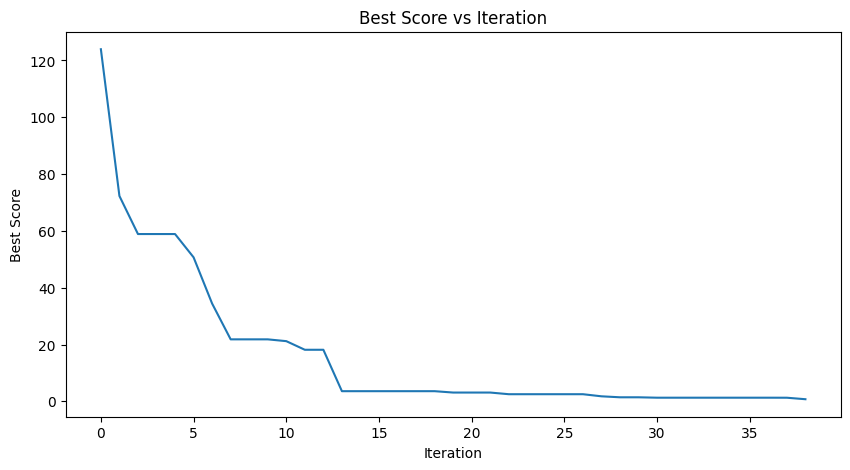

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(iters,best_scores)
plt.xlabel("Iteration")
plt.ylabel("Best Score")
plt.title("Best Score vs Iteration")

In [8]:
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

def plot_ga_3d_gif(history, map_size, filename="ga_evolution.gif", interval=300, elev=25, azim_start=0, azim_step=2):
    iters = sorted(history.keys())[::3]

    # point_size kontrolü - 3D göstermek için ilk 3 boyutu kullanıyoruz
    sample_point = history[iters[0]]["points"][0]
    dim = len(sample_point)
    if dim < 3:
        raise ValueError("3D görselleştirme için point_size en az 3 olmalı")
    if dim > 3:
        print(f"Uyarı: point_size={dim}, sadece ilk 3 boyut çizilecek")

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    def update(frame_idx):
        ax.clear()
        it = iters[frame_idx]
        data = history[it]
        points = np.array(data["points"])
        best_point = np.array(data["best_point"])
        best_score = data["best_score"]

        # tüm popülasyon
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c="royalblue", alpha=0.5, s=30, label="Popülasyon")

        # en iyi nokta
        ax.scatter(best_point[0], best_point[1], best_point[2],
                   c="red", s=120, marker="*", label="En iyi nokta")

        ax.set_xlim(0, map_size)
        ax.set_ylim(0, map_size)
        ax.set_zlim(0, map_size)
        ax.set_title(f"İterasyon {it} | En iyi skor: {best_score:.4f}")
        ax.legend(loc="upper right")
        ax.view_init(elev=elev, azim=azim_start + frame_idx * azim_step)

        return ax,

    anim = FuncAnimation(fig, update, frames=len(iters), interval=interval)
    anim.save(filename, writer=PillowWriter(fps=1000 // interval))
    plt.close(fig)
    print(f"GIF kaydedildi: {filename}")

    return anim

In [9]:
plot_ga_3d_gif(history, map_size=400, filename="ga_evolution.gif")

GIF kaydedildi: ga_evolution.gif
